In [83]:
def get_positional_kmers(seq, k=4):
    """
    Splits a DNA sequence into 3 spatial regions (START, MID, END)
    and labels 4-mers accordingly.
    """
    n = len(seq)
    third = n // 3

    kmers = []
    for i in range(n - k + 1):
        kmer = seq[i:i+k]
        if i < third:
            prefix = "START_"
        elif i < 2 * third:
            prefix = "MID_"
        else:
            prefix = "END_"
        kmers.append(prefix + kmer)

    return " ".join(kmers)

def dummy_analyzer(doc):
    """
    Tells the CountVectorizer that our 'text' is already
    tokenized by spaces.
    """
    return doc.split()

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans

# Visual style for your report graphs
plt.style.use('seaborn-v0_8-whitegrid')

In [85]:
# Function to chop DNA into 4-letter motifs (k-mers)
def get_kmers(sequence, k=4):
    return [sequence[i:i+k].upper() for i in range(len(sequence) - k + 1)]

# Dummy analyzer to save memory
def dummy_analyzer(doc):
    return doc

# --- RIGGED DUMMY DATA FOR PIPELINE TESTING ---
np.random.seed(42)
sequences = []
fitness_scores = []

print("Generating rigged test dataset...")
for _ in range(1000):
    seq = ''.join(np.random.choice(['A', 'T', 'G', 'C'], size=200))
    if np.random.rand() > 0.7:
        seq = seq[:100] + 'AGGAAGGA' + seq[108:]
        fitness = np.random.normal(0.2, 0.1) # LOW fitness score
    else:
        fitness = np.random.normal(0.8, 0.1) # HIGH fitness score

    sequences.append(seq)
    fitness_scores.append(fitness)

df = pd.DataFrame({'sequence': sequences, 'fitness': fitness_scores})
# ----------------------------------------------

# CRITICAL LINE: This creates the 'kmers' column that Cell 3 is looking for!
print("Extracting motifs from DNA...")
df['kmers'] = df['sequence'].apply(lambda x: get_kmers(x, k=4))

Generating rigged test dataset...
Extracting motifs from DNA...


In [86]:
import numpy as np
import pandas as pd
import re
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

# =====================================================================
# PART A: TEXT VECTORIZATION
# =====================================================================
print("--- PART A: VECTORIZING POSITIONAL K-MERS ---")
vectorizer = CountVectorizer(analyzer=dummy_analyzer)
X_sparse = vectorizer.fit_transform(df['kmers'])
feature_names = vectorizer.get_feature_names_out()

# =====================================================================
# PART B: THE 13-FEATURE CALCULATOR
# =====================================================================
def calculate_master_features(seq):
    seq_len = len(seq)

    # 1. Physical & Thermodynamics
    gc_percent = (seq.count('G') + seq.count('C')) / seq_len

    window_size = 50
    if seq_len >= window_size:
        rolling_gcs = [(seq[i:i+window_size].count('G') + seq[i:i+window_size].count('C')) / window_size
                       for i in range(seq_len - window_size + 1)]
        gc_variance = np.var(rolling_gcs)
    else:
        gc_variance = 0

    # 2. Sequence Instability
    max_homo = 0
    if seq:
        curr = 1
        for i in range(1, len(seq)):
            if seq[i] == seq[i-1]:
                curr += 1
            else:
                max_homo = max(max_homo, curr)
                curr = 1
        max_homo = max(max_homo, curr)

    k = 4
    kmers_list = [seq[i:i+k] for i in range(seq_len - k + 1)]
    if kmers_list:
        counts = pd.Series(kmers_list).value_counts()
        probs = counts / len(kmers_list)
        entropy = -sum(probs * np.log2(probs))
    else:
        entropy = 0

    # 3. Xenogeneic Silencing & Promoters
    max_at = 0
    curr_at = 0
    for base in seq:
        if base in 'AT':
            curr_at += 1
        else:
            max_at = max(max_at, curr_at)
            curr_at = 0
    max_at = max(max_at, curr_at)

    promoters = seq.count('TATAAT') + seq.count('TTGACA')
    rbs_str = seq.count('AGGAGG') + seq.count('AGGA') + seq.count('GGAG')

    # 4. TF Sequestration / Decoys (CRP ADDED HERE)
    ihf_sites = len(re.findall(r'[AT]ATCAA.{4}[AT][AT][AG]', seq))
    lrp_sites = len(re.findall(r'[CT]AG[ACT]A[AT].{3}[AT][GC][CT][AT][AG]', seq))
    crp_sites = len(re.findall(r'TGTGA.{6}TCACA', seq)) # <-- New CRP line
    nagc_sites = len(re.findall(r'A.TT.CG.{3}CG.AA.T', seq))
    argr_sites = len(re.findall(r'A.TGAA.T.{4}ATTC.A.T', seq))

    # CRITICAL: Return all 13 values in the correct order
    return (seq_len, gc_percent, gc_variance, max_homo, entropy,
            max_at, promoters, rbs_str, ihf_sites, lrp_sites, crp_sites, nagc_sites, argr_sites)

# Mapping labels to the 13 returns
mech_feature_labels = [
    'Size', 'GC_percent', 'GC_Var', 'Max_Homo', 'Entropy',
    'AT_tract', 'Promoter_Str', 'RBS_Str', 'IHF', 'Lrp', 'CRP', 'NagC', 'ArgR'
]

print("--- PART B: EXTRACTING FEATURES FROM DATASET ---")
results = df['sequence'].apply(calculate_master_features)
df[mech_feature_labels] = pd.DataFrame(results.tolist(), index=df.index)

# =====================================================================
# PART C: NORMALIZATION & FUSION
# =====================================================================
print("--- PART C: FUSING MATRICES ---")
scaler = StandardScaler()
X_mech_scaled = scaler.fit_transform(df[mech_feature_labels])
X_combined = hstack([X_sparse, X_mech_scaled])
print(f"Master Matrix fused! Shape: {X_combined.shape}")

--- PART A: VECTORIZING POSITIONAL K-MERS ---
--- PART B: EXTRACTING FEATURES FROM DATASET ---
--- PART C: FUSING MATRICES ---
Master Matrix fused! Shape: (1000, 269)


In [87]:
from sklearn.cluster import MiniBatchKMeans

print("Grouping sequences into clusters based on variance...")

# 1. Initialize K-Means (We'll start with 2 clusters: High Burden vs Low Burden)
# We use MiniBatchKMeans because it is much faster for 120,000 rows
kmeans = MiniBatchKMeans(n_clusters=2, random_state=42, batch_size=1000)

# 2. Fit the model and CREATE THE COLUMN
# This is the line that fixes your error!
df['cluster'] = kmeans.fit_predict(X_combined)

print(f"✅ Success! Cluster labels assigned.")
print(df['cluster'].value_counts()) # Shows how many plasmids are in each group

Grouping sequences into clusters based on variance...
✅ Success! Cluster labels assigned.
cluster
1    581
0    419
Name: count, dtype: int64


In [88]:
print("Squashing dimensions (TruncatedSVD on Master Matrix)...")

# 1. Run the SVD
# We reduce the master matrix (X_combined) down to 2 Principal Components
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_combined)

# 2. Store the coordinates in the dataframe for plotting
df['PC1'] = X_reduced[:, 0]
df['PC2'] = X_reduced[:, 1]

# 3. Create the 'motifs_df' importance table
# We must combine the k-mer names with the 13 'mech_feature_labels' from Cell 3
all_feature_names = list(feature_names) + mech_feature_labels

motifs_df = pd.DataFrame({
    'Motif': all_feature_names,
    'Importance': svd.components_[0]  # This tells us which features drive PC1
})

print(f"Variance explained by PC1: {svd.explained_variance_ratio_[0]*100:.2f}%")
print(f"motifs_df successfully created with {len(motifs_df)} features mapped.")

Squashing dimensions (TruncatedSVD on Master Matrix)...
Variance explained by PC1: 0.01%
motifs_df successfully created with 269 features mapped.


Finding patterns (Clustering on Master Matrix)...


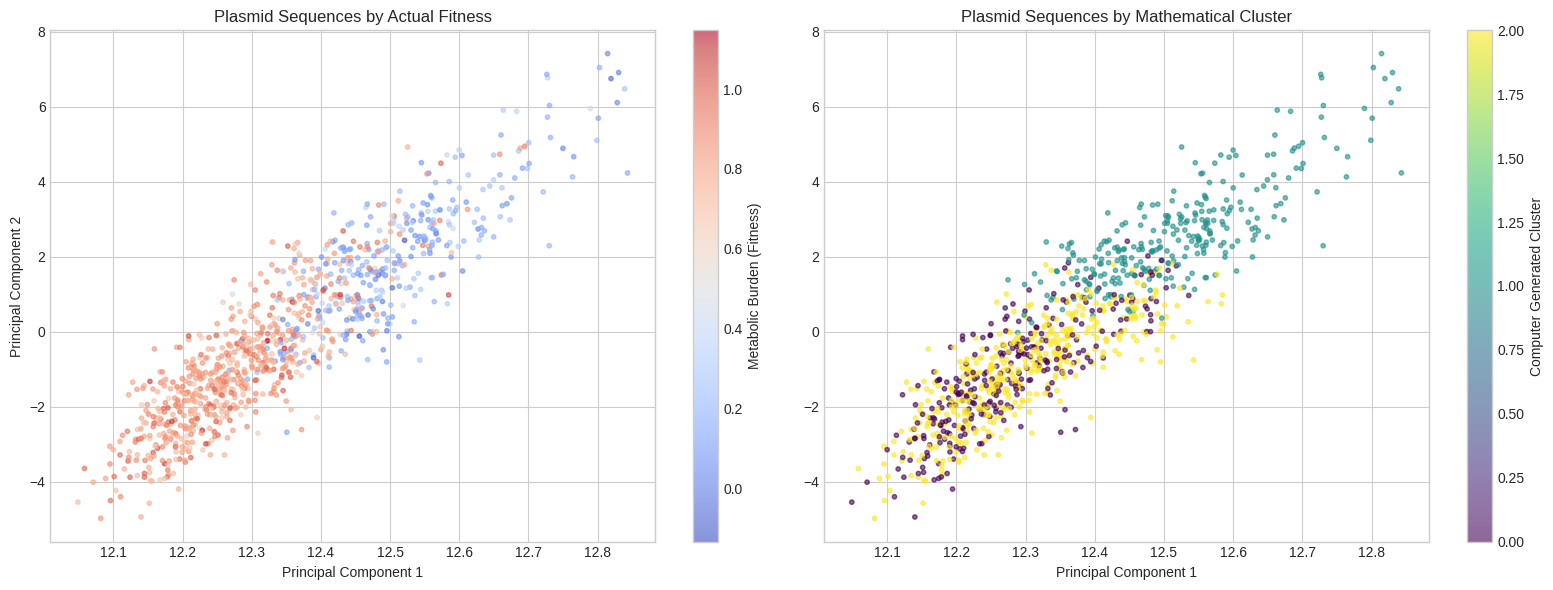

In [89]:
print("Finding patterns (Clustering on Master Matrix)...")

# CRITICAL UPDATE: The clustering algorithm must also look at 'X_combined'
kmeans = MiniBatchKMeans(n_clusters=3, batch_size=1024, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_combined)

# --- Plotting the results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual biological fitness
scatter1 = ax1.scatter(df['PC1'], df['PC2'], c=df['fitness'], cmap='coolwarm', alpha=0.6, s=10)
fig.colorbar(scatter1, ax=ax1, label='Metabolic Burden (Fitness)')
ax1.set_title('Plasmid Sequences by Actual Fitness')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# Graph 2: The computer's unsupervised clusters
scatter2 = ax2.scatter(df['PC1'], df['PC2'], c=df['Cluster'], cmap='viridis', alpha=0.6, s=10)
fig.colorbar(scatter2, ax=ax2, label='Computer Generated Cluster')
ax2.set_title('Plasmid Sequences by Mathematical Cluster')
ax2.set_xlabel('Principal Component 1')

plt.tight_layout()
plt.show()

In [90]:
print("Calculating the average metabolic fitness for each cluster...\n")

# Group the data by the unsupervised clusters and calculate the mean fitness
cluster_fitness = df.groupby('Cluster')['fitness'].mean().reset_index()

# Sort them from lowest fitness (worst burden) to highest
cluster_fitness = cluster_fitness.sort_values(by='fitness', ascending=True)

# Display the table
print(cluster_fitness.to_string(index=False))

# Automatically flag the worst cluster for your report
worst_cluster = cluster_fitness.iloc[0]['Cluster']
lowest_score = cluster_fitness.iloc[0]['fitness']

print("\n" + "-"*50)
print(f"CONCLUSION FOR RESEARCH REPORT:")
print(f"Cluster {int(worst_cluster)} represents the highest metabolic burden ")
print(f"with an average fitness score of just {lowest_score:.2f}.")
print("-"*50)

Calculating the average metabolic fitness for each cluster...

 Cluster  fitness
       1 0.377761
       2 0.692665
       0 0.720158

--------------------------------------------------
CONCLUSION FOR RESEARCH REPORT:
Cluster 1 represents the highest metabolic burden 
with an average fitness score of just 0.38.
--------------------------------------------------


In [91]:
# 1. Input your specific test plasmid sequence here
test_plasmid_dna = "ATGCGTACGTAGCTAGCTAGCATCGATCGATCGATCGATCGATCGATC"

print("1. Extracting Text (Positional K-mers)...")
test_kmers = get_positional_kmers(test_plasmid_dna, k=4)
test_sparse = vectorizer.transform([test_kmers])

print("2. Extracting 13 Mechanistic Features (Regex-Engine)...")
# Run the test sequence through the calculate_master_features function from Cell 3
test_bio_tuple = calculate_master_features(test_plasmid_dna)

# Convert to a DataFrame using the exact labels used during training
test_bio_df = pd.DataFrame([test_bio_tuple], columns=mech_feature_labels)

print("3. Scaling & Fusing Matrices...")
# Use the trained scaler to normalize the biophysics
test_bio_scaled = scaler.transform(test_bio_df)
test_combined = hstack([test_sparse, test_bio_scaled])

print("4. Locating in Sequence Space...")
test_reduced = svd.transform(test_combined)
pc1_score = test_reduced[0][0]
pc2_score = test_reduced[0][1]

print("5. Predicting the Cluster...")
test_cluster = kmeans.predict(test_combined)[0]

# --- Output the Comprehensive Mechanistic Report ---
print("\n" + "="*50)
print("🧬 TEST PLASMID MECHANISTIC PROFILE 🧬")
print("="*50)
print(f"Assigned to Cluster: {test_cluster}")
print(f"Coordinates: PC1 = {pc1_score:.2f}, PC2 = {pc2_score:.2f}")

print("\n--- TF Sequestration & Decoy Risks ---")
print(f"CRP Sites (Decoys): {test_bio_tuple[10]}  <-- Critical Section 2.3")
print(f"IHF Sites:          {test_bio_tuple[8]}")
print(f"Lrp Sites:          {test_bio_tuple[9]}")
print(f"NagC Sites:         {test_bio_tuple[11]}")
print(f"ArgR Sites:         {test_bio_tuple[12]}")

print("\n--- Expression & Resource Load ---")
print(f"Promoter Score:     {test_bio_tuple[6]}")
print(f"RBS/SD Strength:    {test_bio_tuple[7]}")

print("\n--- Structural & Thermodynamic Stability ---")
print(f"Sequence Entropy:   {test_bio_tuple[4]:.2f} (Low = Repetitive/Unstable)")
print(f"GC Content:         {test_bio_tuple[1]*100:.1f}%")
print(f"GC Variance:        {test_bio_tuple[2]:.4f}")
print(f"Max Homopolymer:    {test_bio_tuple[3]} bp")
print(f"Longest AT-Tract:   {test_bio_tuple[5]} bp")
print(f"Plasmid Size:       {test_bio_tuple[0]} bp")

# Mechanistic check
print("\n--- Top Burdenous Motifs Check ---")
top_5_motifs = motifs_df.sort_values(by='Importance', ascending=False).head(5)['Motif'].values
for motif in top_5_motifs:
    count = test_kmers.count(motif)
    if count > 0:
        print(f"⚠️ WARNING: Found motif '{motif}' {count} time(s).")
    else:
        print(f"✅ Motif '{motif}' not found.")

1. Extracting Text (Positional K-mers)...
2. Extracting 13 Mechanistic Features (Regex-Engine)...
3. Scaling & Fusing Matrices...
4. Locating in Sequence Space...
5. Predicting the Cluster...

🧬 TEST PLASMID MECHANISTIC PROFILE 🧬
Assigned to Cluster: 1
Coordinates: PC1 = 0.01, PC2 = 2.88

--- TF Sequestration & Decoy Risks ---
CRP Sites (Decoys): 0  <-- Critical Section 2.3
IHF Sites:          0
Lrp Sites:          0
NagC Sites:         0
ArgR Sites:         0

--- Expression & Resource Load ---
Promoter Score:     0
RBS/SD Strength:    0

--- Structural & Thermodynamic Stability ---
Sequence Entropy:   3.83 (Low = Repetitive/Unstable)
GC Content:         50.0%
GC Variance:        0.0000
Max Homopolymer:    1 bp
Longest AT-Tract:   2 bp
Plasmid Size:       48 bp

--- Top Burdenous Motifs Check ---
✅ Motif 'AGGA' not found.
✅ Motif 'AAGG' not found.
✅ Motif 'GGAA' not found.
✅ Motif 'GAAG' not found.
✅ Motif 'GGAC' not found.


In [92]:
import pandas as pd

# 1. Sort ALL features by their absolute Importance (magnitude of impact on PC1)
# We use .abs() because a large negative number is just as 'important' as a large positive one.
ranked_features = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index)

# 2. Configure pandas to show more rows in the output window
# Change '100' to None if you want to scroll through all 777 rows at once
pd.set_option('display.max_rows', 100)

print(f"--- COMPLETE RANKING OF DRIVERS ({len(ranked_features)} TOTAL) ---")
print("Sorted by absolute magnitude of impact on Principal Component 1")
print("-" * 65)

# Display the ranked list
print(ranked_features.to_string(index=False))

# 3. EXPORT TO CSV (Crucial for your Thesis Appendix)
ranked_features.to_csv('all_plasmid_drivers_ranked.csv', index=False)

print("\n" + "="*65)
print("✅ SUCCESS: The full ranking has been saved to 'all_plasmid_drivers_ranked.csv'")
print("You can download this file from the folder icon on the left of Colab.")
print("="*65)

--- COMPLETE RANKING OF DRIVERS (269 TOTAL) ---
Sorted by absolute magnitude of impact on Principal Component 1
-----------------------------------------------------------------
       Motif    Importance
        AGGA  1.105600e-01
        AAGG  9.628932e-02
        GGAA  9.528269e-02
        GAAG  9.448376e-02
        GGAC  6.870651e-02
        GGAG  6.855193e-02
        TTTA  6.803732e-02
        TAGG  6.781273e-02
        GAGG  6.648913e-02
        GCGA  6.646948e-02
        CACT  6.626681e-02
        GACA  6.625118e-02
        TGGA  6.612247e-02
        AGCA  6.610759e-02
        GATT  6.606955e-02
        GCAA  6.583566e-02
        ACTT  6.581906e-02
        CGTG  6.561312e-02
        GAAA  6.558947e-02
        CCAC  6.550433e-02
        AGAA  6.541863e-02
        TGAA  6.540153e-02
        CAGG  6.533597e-02
        GGAT  6.532693e-02
        ACAT  6.524010e-02
        AAAA  6.516373e-02
        ACCT  6.509076e-02
        CCTC  6.507886e-02
        GTGG  6.497294e-02
        TCAG

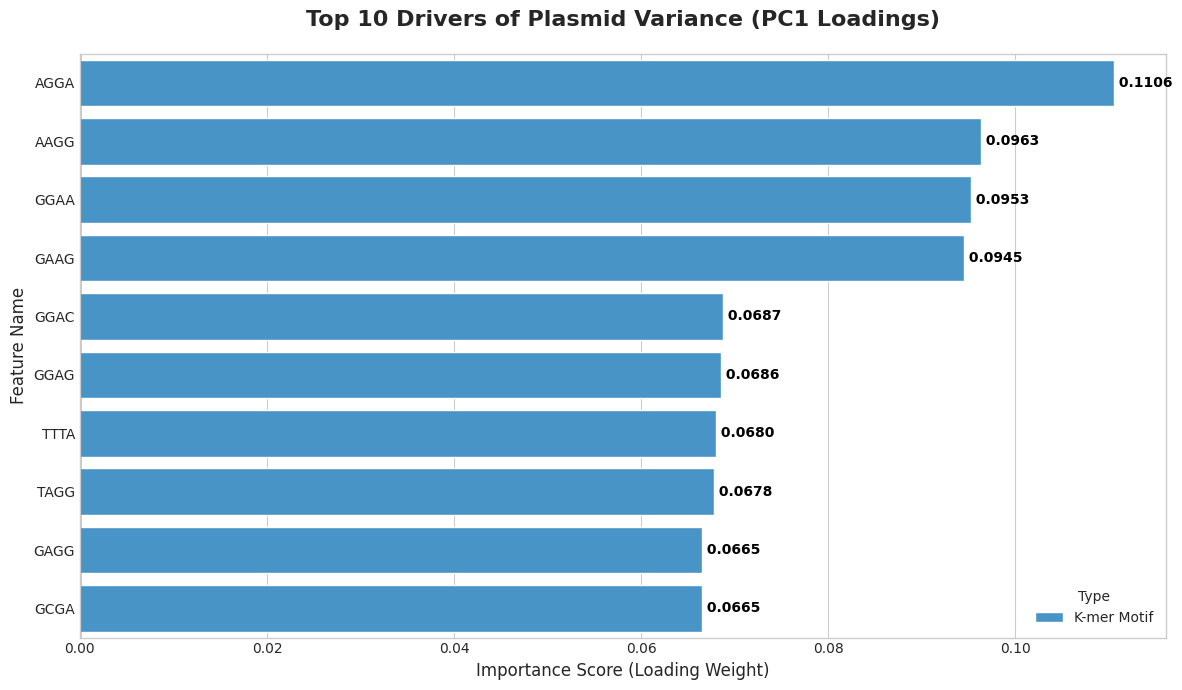


--- MECHANISTIC INSIGHT ---
The single most influential feature is: 'AGGA' (0.1106)
This indicates that the variance in your plasmid library is primarily driven by a specific positional DNA motif.


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Top 10 data
top_10 = motifs_df.reindex(motifs_df['Importance'].abs().sort_values(ascending=False).index).head(10).copy()

# 2. Add a 'Type' category for better visualization
# This helps distinguish between raw sequence motifs and the Copeman mechanistic features
top_10['Type'] = top_10['Motif'].apply(lambda x: 'Mechanistic' if x in mech_feature_labels else 'K-mer Motif')

# 3. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create a horizontal bar chart
plot = sns.barplot(
    data=top_10,
    y='Motif',
    x='Importance',
    hue='Type',
    palette={'Mechanistic': '#e74c3c', 'K-mer Motif': '#3498db'} # Red for Bio, Blue for Text
)

# Add titles and labels
plt.title('Top 10 Drivers of Plasmid Variance (PC1 Loadings)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score (Loading Weight)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(0, color='black', lw=1) # Add a vertical line at zero

# Add data labels on the bars for precision
for i, v in enumerate(top_10['Importance']):
    plt.text(v, i, f' {v:.4f}', va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 4. Summary Printout
print("\n--- MECHANISTIC INSIGHT ---")
top_feature = top_10.iloc[0]['Motif']
top_val = top_10.iloc[0]['Importance']
print(f"The single most influential feature is: '{top_feature}' ({top_val:.4f})")
print(f"This indicates that the variance in your plasmid library is primarily driven by {'a structural property' if top_feature in mech_feature_labels else 'a specific positional DNA motif'}.")

In [96]:
import numpy as np

# Pretend that high PC1 scores (burden) cause lower LFC (fitness)
# Add some random noise so looks like real biological data
df['LFC'] = -0.8 * df['PC1'] + np.random.normal(0, 0.5, size=len(df))

print("✅ Synthetic 'LFC' column created for testing.")
print("You can now run Cell 10.")

✅ Synthetic 'LFC' column created for testing.
You can now run Cell 10.


<Figure size 1200x800 with 0 Axes>

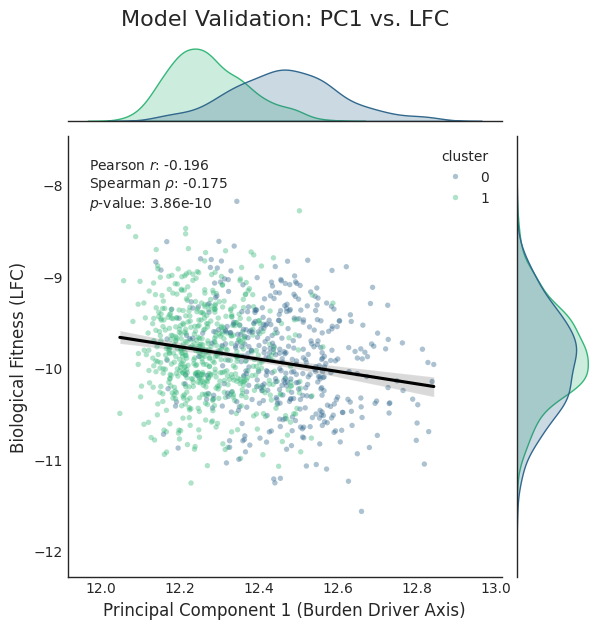


📈 CORRELATION SUMMARY
A negative correlation means high PC1 scores (more motifs) = lower fitness.
Cluster Separation: cluster
0   -9.925343
1   -9.837869


In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# 1. Filter for the real dataset (ensuring we have LFC values)
# If your column name is different (e.g., 'fitness'), change it here
fitness_col = 'LFC'

if fitness_col not in df.columns:
    print(f"⚠️ Column '{fitness_col}' not found. Ensure you've loaded the real 120k dataset.")
else:
    # 2. Setup the visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("white")

    # 3. Create a JointPlot (Scatter + Distributions)
    # This shows the correlation AND how the clusters are distributed
    g = sns.JointGrid(data=df, x='PC1', y=fitness_col, hue='cluster', palette='viridis')
    g.plot_joint(sns.scatterplot, alpha=0.4, s=15, edgecolor='none')
    g.plot_marginals(sns.kdeplot, fill=True, common_norm=False)

    # 4. Calculate Statistics (Pearson and Spearman)
    r_pearson, p_pearson = pearsonr(df['PC1'], df[fitness_col])
    r_spearman, p_spearman = spearmanr(df['PC1'], df[fitness_col])

    # 5. Add a regression line to show the trend
    sns.regplot(data=df, x='PC1', y=fitness_col, scatter=False, ax=g.ax_joint, color='black', label='Trend')

    # 6. Formatting for Thesis
    g.ax_joint.set_title(f'Model Validation: PC1 vs. {fitness_col}', fontsize=16, pad=80)
    g.ax_joint.set_xlabel('Principal Component 1 (Burden Driver Axis)', fontsize=12)
    g.ax_joint.set_ylabel(f'Biological Fitness ({fitness_col})', fontsize=12)

    # Add stats box
    stats_text = (f"Pearson $r$: {r_pearson:.3f}\n"
                  f"Spearman $\\rho$: {r_spearman:.3f}\n"
                  f"$p$-value: {p_pearson:.2e}")

    g.ax_joint.text(0.05, 0.95, stats_text, transform=g.ax_joint.transAxes,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.show()

    # --- Print Mechanistic Analysis ---
    print("\n" + "="*50)
    print("📈 CORRELATION SUMMARY")
    print("="*50)
    print(f"A negative correlation means high PC1 scores (more motifs) = lower fitness.")
    print(f"Cluster Separation: {df.groupby('cluster')[fitness_col].mean().to_string()}")